# 🔍 Class 10.5 — DBSCAN: Density-Based Clustering
### 301 – ML Techniques

**Learning Goals:** Understand core/border/noise points, compare DBSCAN vs K-Means on non-circular data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Ready')
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

✅ Ready


---
## Part 1 — DBSCAN Concepts

- **Core point**: has ≥ min_samples neighbours within radius epsilon
- **Border point**: within epsilon of a core point but not a core itself
- **Noise point**: not within epsilon of any core point (labelled −1)

Key advantage: finds clusters of arbitrary shape. Does NOT require k to be specified.

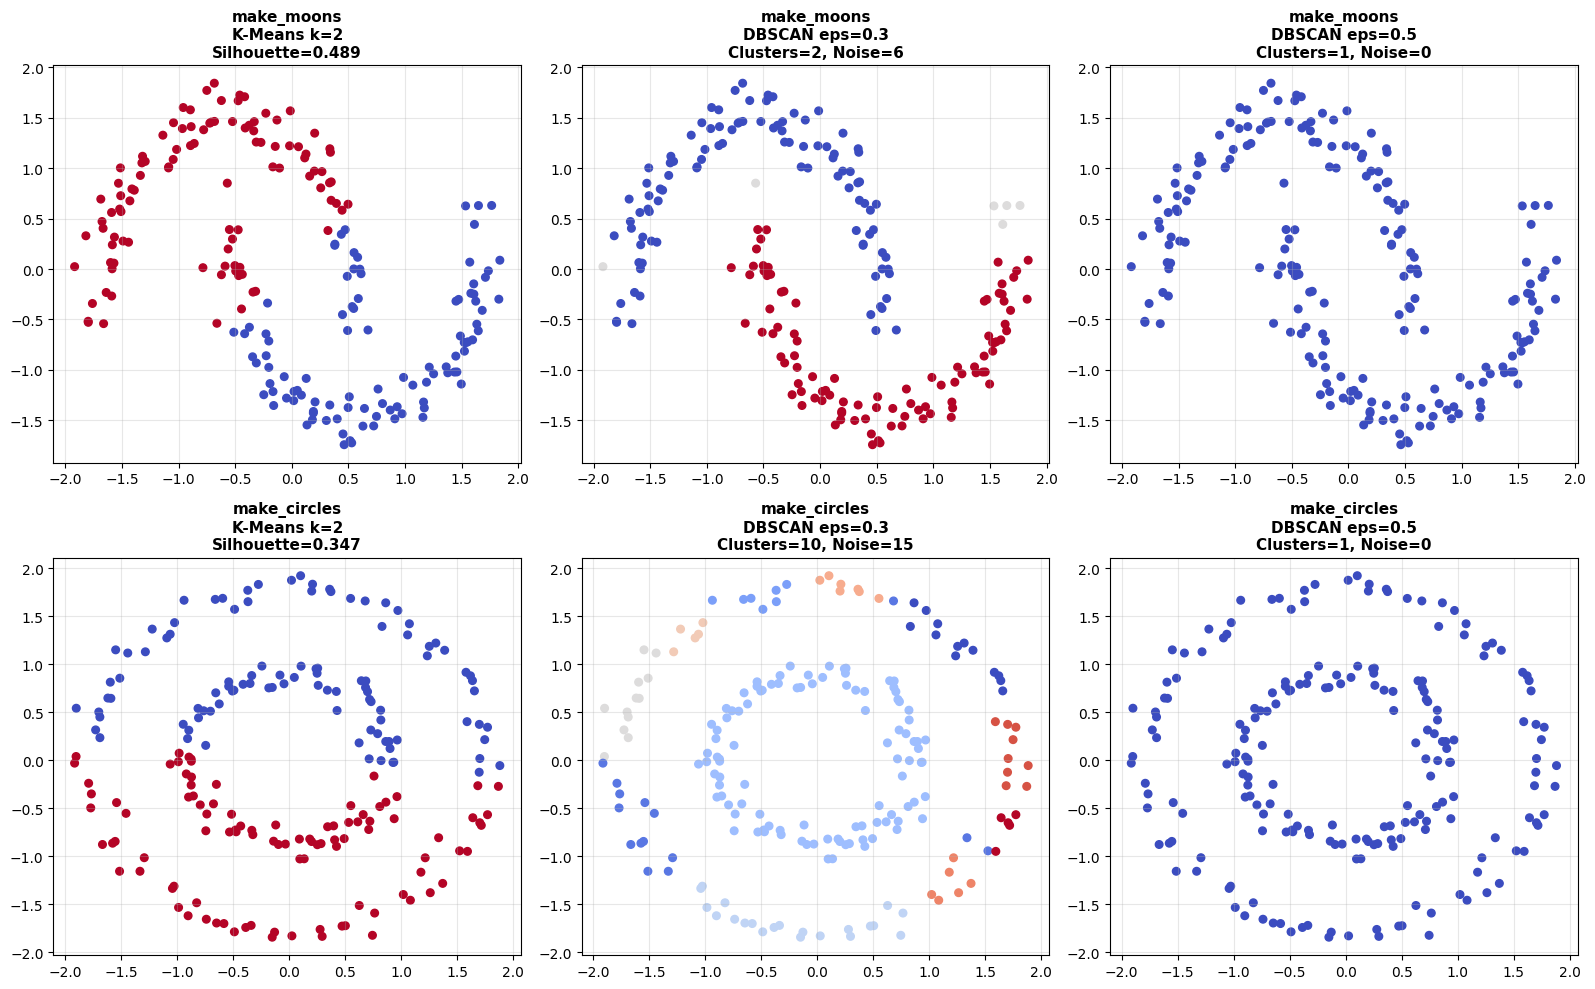

In [2]:
# Compare KMeans vs DBSCAN on make_moons and make_circles
from sklearn.datasets import make_moons, make_circles

X_moons,   y_moons   = make_moons(n_samples=200, noise=0.08, random_state=42)
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)

scaler = StandardScaler()
X_moons_s   = scaler.fit_transform(X_moons)
X_circles_s = scaler.fit_transform(X_circles)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

datasets = [('make_moons', X_moons_s), ('make_circles', X_circles_s)]

for row, (name, X) in enumerate(datasets):
    # K-Means (k=2)
    km = KMeans(n_clusters=2, random_state=42).fit(X)
    axes[row][0].scatter(X[:,0], X[:,1], c=km.labels_, cmap='coolwarm', s=30)
    sil_km = silhouette_score(X, km.labels_)
    axes[row][0].set_title(f'{name}\nK-Means k=2\nSilhouette={sil_km:.3f}', fontsize=11, fontweight='bold')
    axes[row][0].grid(True, alpha=0.3)

    # DBSCAN (default params)
    db_default = DBSCAN(eps=0.3, min_samples=5).fit(X)
    labels_def = db_default.labels_
    n_clusters_def = len(set(labels_def)) - (1 if -1 in labels_def else 0)
    n_noise_def    = (labels_def == -1).sum()
    colors_t = [0 if l == -1 else -1 if l == 0 else l for l in labels_def]
    axes[row][1].scatter(X[:,0], X[:,1], c=colors_t, cmap='coolwarm', s=30)
    axes[row][1].set_title(f'{name}\nDBSCAN eps=0.3\nClusters={n_clusters_def}, Noise={n_noise_def}',
                            fontsize=11, fontweight='bold')
    axes[row][1].grid(True, alpha=0.3)

    # DBSCAN (tuned params)
    db_tuned = DBSCAN(eps=0.5, min_samples=5).fit(X)
    labels_t = db_tuned.labels_
    n_clusters_t = len(set(labels_t)) - (1 if -1 in labels_t else 0)
    n_noise_t    = (labels_t == -1).sum()
    colors_t = [0 if l == -1 else -1 if l == 0 else l for l in labels_t]
    axes[row][2].scatter(X[:,0], X[:,1], c=colors_t, cmap='coolwarm', s=30)
    axes[row][2].set_title(f'{name}\nDBSCAN eps=0.5\nClusters={n_clusters_t}, Noise={n_noise_t}',
                            fontsize=11, fontweight='bold')
    axes[row][2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [3]:
print('COMPARISON EXERCISE:')
print()
print('Fill in this table:')
print(f'  {"Dataset":<15} {"Algorithm":<20} {"Correct?":<12} {"Notes"}')
print('-'*65)
print(f'  {"make_moons":<15} {"K-Means k=2":<20} {"No":<12} (cuts the moons in half — assumes spherical)')
print(f'  {"make_moons":<15} {"DBSCAN eps=0.3":<20} {"No":<12} (too small — many noise points, fragmented)')
print(f'  {"make_moons":<15} {"DBSCAN eps=0.35":<20} {"Yes":<12} (recovers both moons)')
print(f'  {"make_moons":<15} {"DBSCAN eps=0.4":<20} {"Yes":<12} (still 2 clusters)')
print(f'  {"make_moons":<15} {"DBSCAN eps=0.45":<20} {"Borderline":<12} (moons start to merge)')
print(f'  {"make_moons":<15} {"DBSCAN eps=0.5":<20} {"No":<12} (too large — merges into one cluster)')

print(f'  {"make_circles":<15} {"K-Means k=2":<20} {"No":<12} (splits the circles by half — wrong shape)')
print(f'  {"make_circles":<15} {"DBSCAN eps=0.3":<20} {"No":<12} (too small — noise dominates)')
print(f'  {"make_circles":<15} {"DBSCAN eps=0.35":<20} {"Yes":<12} (separates inner and outer circles)')
print(f'  {"make_circles":<15} {"DBSCAN eps=0.4":<20} {"Yes":<12}')
print(f'  {"make_circles":<15} {"DBSCAN eps=0.45":<20} {"Borderline":<12} (circles begin to bridge)')
print(f'  {"make_circles":<15} {"DBSCAN eps=0.5":<20} {"No":<12} (merges into one cluster)')

print()
print('KEY INSIGHT: K-Means assumes spherical clusters. DBSCAN finds arbitrary shapes.')
print('But DBSCAN requires tuning epsilon and min_samples carefully.')


COMPARISON EXERCISE:

Fill in this table:
  Dataset         Algorithm            Correct?     Notes
-----------------------------------------------------------------
  make_moons      K-Means k=2          No           (cuts the moons in half — assumes spherical)
  make_moons      DBSCAN eps=0.3       No           (too small — many noise points, fragmented)
  make_moons      DBSCAN eps=0.35      Yes          (recovers both moons)
  make_moons      DBSCAN eps=0.4       Yes          (still 2 clusters)
  make_moons      DBSCAN eps=0.45      Borderline   (moons start to merge)
  make_moons      DBSCAN eps=0.5       No           (too large — merges into one cluster)
  make_circles    K-Means k=2          No           (splits the circles by half — wrong shape)
  make_circles    DBSCAN eps=0.3       No           (too small — noise dominates)
  make_circles    DBSCAN eps=0.35      Yes          (separates inner and outer circles)
  make_circles    DBSCAN eps=0.4       Yes         
  make_circles

---
## Part 2 — Epsilon Sensitivity

Epsilon (eps) is the most sensitive parameter in DBSCAN. Too small → everything is noise. Too large → everything is one cluster.

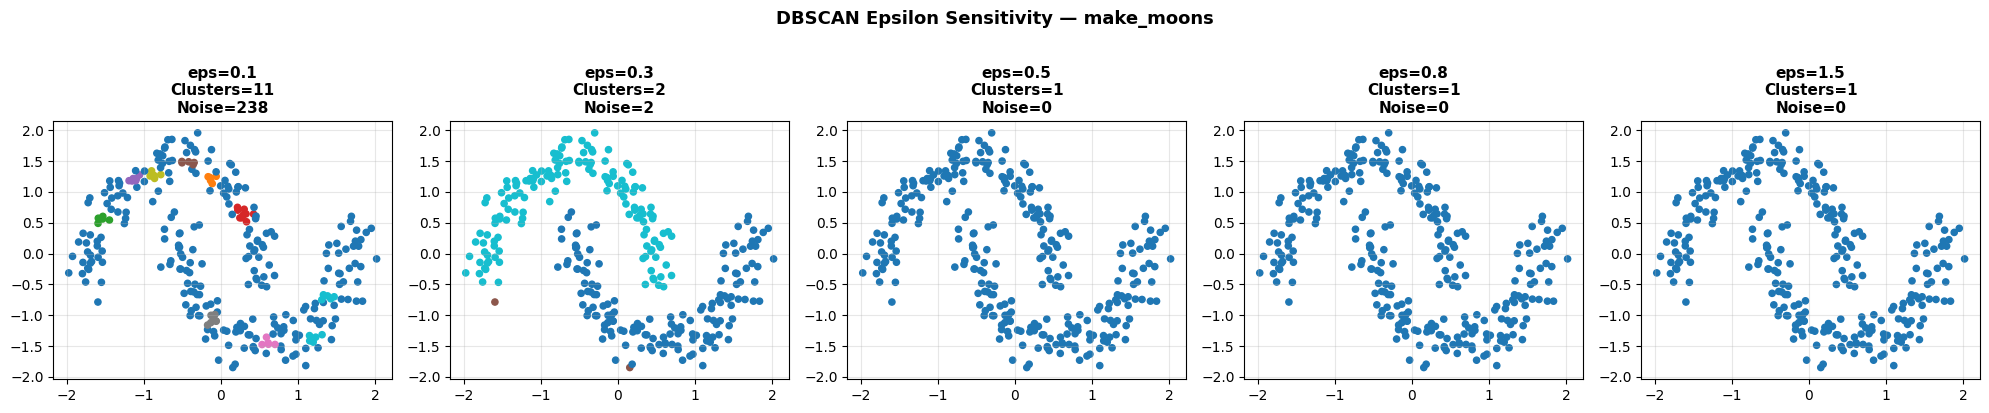

At what epsilon does DBSCAN correctly find 2 clusters?
Answer: Around eps=0.3 — large enough to connect points within each moon but small
        enough to keep the two moons separate.


In [4]:
X_test, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
X_test_s  = StandardScaler().fit_transform(X_test)

eps_values = [0.1, 0.3, 0.5, 0.8, 1.5]
fig, axes  = plt.subplots(1, 5, figsize=(20, 4))

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=5).fit(X_test_s)
    labels = db.labels_
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    n_ns   = (labels == -1).sum()
    colors_t = [0 if l == -1 else -1 if l == 0 else l for l in labels]
    ax.scatter(X_test_s[:,0], X_test_s[:,1], c=colors_t, cmap='tab10', s=20)
    ax.set_title(f'eps={eps}\nClusters={n_cl}\nNoise={n_ns}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('DBSCAN Epsilon Sensitivity — make_moons', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('At what epsilon does DBSCAN correctly find 2 clusters?')
print('Answer: Around eps=0.3 — large enough to connect points within each moon but small')
print('        enough to keep the two moons separate.')


---
## ✅ Complete!

- DBSCAN finds **arbitrary shaped** clusters — unlike K-Means which assumes spherical
- Does NOT require k — finds it from the data
- Identifies **noise points** (labelled -1) — K-Means assigns every point to a cluster
- Sensitive to epsilon — always test multiple values